In [1]:
from pathlib import Path
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import NumericType

spark = (
    SparkSession.builder
    .appName("BNPL Tables EDA")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

TABLES_DIR = Path.cwd() / "tables"
print(f"Reading datasets from: {TABLES_DIR}")
print(f"Spark version: {spark.version}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/22 14:23:09 WARN Utils: Your hostname, Trinh2in1PC, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/09/22 14:23:09 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/22 14:23:11 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/22 14:23:12 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Reading datasets from: /mnt/c/Users/werew/Downloads/MAST30034_Project_2/tables
Spark version: 4.2.0


## Load every dataset

The loaders preserve the source formats and use schema inference for the CSV files. The pipe-delimited consumer table is handled explicitly.

In [6]:
TABLES_DIR = Path.cwd() / "data/tables"


def read_partitioned_parquet(path):
    path = Path(path)
    if not path.exists():
        return None
    try:
        return spark.read.option("basePath", str(path)).parquet(str(path))
    except Exception as exc:
        print(f"Could not load partitioned parquet dataset from {path}: {exc}")
        return None


def load_dataset(name, path, file_type, delimiter=None):
    path = Path(path)
    if not path.exists():
        print(f"Skipping {name}: {path} does not exist")
        return None

    reader = spark.read.option("header", True).option("inferSchema", True)
    if file_type == "csv":
        return reader.option("sep", delimiter).option("quote", '"').csv(str(path))
    return reader.parquet(str(path))


datasets = {}

transaction_frames = []
for part_name in ["part_2", "part_3", "part_4"]:
    part_path = TABLES_DIR / part_name
    dataframe = read_partitioned_parquet(part_path)
    if dataframe is not None:
        transaction_frames.append(dataframe)

if transaction_frames:
    transactions = transaction_frames[0]
    for dataframe in transaction_frames[1:]:
        transactions = transactions.unionByName(dataframe, allowMissingColumns=True)
    datasets["transactions"] = transactions

for name, dataframe in datasets.items():
    print(f"{name}: {dataframe.count():,} rows x {len(dataframe.columns)} columns")


transactions: 14,195,505 rows x 5 columns


## Exploratory summaries

For each table, the cells below report schema, missing values, distinct values, numeric distributions, date ranges, and the most common categorical values.

In [7]:
def show_eda(name, dataframe, top_n=5):
    print(f"\n{'=' * 80}\n{name}\n{'=' * 80}")
    print("Schema:")
    dataframe.printSchema()

    row_count = dataframe.count()
    missing_expressions = []
    distinct_expressions = []
    for field in dataframe.schema.fields:
        column = F.col(field.name)
        missing_condition = column.isNull()
        if field.dataType.simpleString() == "string":
            missing_condition = missing_condition | (F.trim(column) == "")
        missing_expressions.append(
            F.sum(F.when(missing_condition, 1).otherwise(0)).alias(f"{field.name}_missing")
        )
        distinct_expressions.append(F.approx_count_distinct(column).alias(field.name))

    missing_counts = dataframe.agg(*missing_expressions).first().asDict()
    distinct_counts = dataframe.agg(*distinct_expressions).first().asDict()
    quality_rows = [
        (field.name, field.dataType.simpleString(), distinct_counts[field.name],
         missing_counts[f"{field.name}_missing"],
         round(100 * missing_counts[f"{field.name}_missing"] / row_count, 2))
        for field in dataframe.schema.fields
    ]
    quality = spark.createDataFrame(
        quality_rows,
        ["column", "data_type", "approx_distinct", "missing", "missing_pct"],
    )
    print(f"Rows: {row_count:,}")
    print("Column quality:")
    quality.show(truncate=False)

    numeric_columns = [
        field.name for field in dataframe.schema.fields
        if isinstance(field.dataType, NumericType)
    ]
    if numeric_columns:
        print("Numeric summaries:")
        dataframe.select(numeric_columns).describe().show(truncate=False)

    date_columns = [
        field.name for field in dataframe.schema.fields
        if "date" in field.name.lower() or "time" in field.name.lower()
    ]
    for column_name in date_columns:
        date_range = dataframe.select(
            F.min(F.to_date(F.col(column_name))).alias("min_date"),
            F.max(F.to_date(F.col(column_name))).alias("max_date"),
        ).first()
        if date_range is not None:
            print(f"{column_name}: {date_range['min_date']} to {date_range['max_date']}")

    categorical_columns = [
        field.name for field in dataframe.schema.fields
        if field.dataType.simpleString() == "string"
    ]
    for column_name in categorical_columns:
        print(f"Top values for {column_name}:")
        (dataframe.groupBy(column_name)
         .count()
         .orderBy(F.desc("count"), F.asc_nulls_last(column_name))
         .show(top_n, truncate=False))


for dataset_name, dataset in datasets.items():
    show_eda(dataset_name, dataset)



transactions
Schema:
root
 |-- user_id: long (nullable = true)
 |-- merchant_abn: long (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)



26/09/22 14:26:12 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Rows: 14,195,505
Column quality:


+--------------+---------+---------------+-------+-----------+
|column        |data_type|approx_distinct|missing|missing_pct|
+--------------+---------+---------------+-------+-----------+
|user_id       |bigint   |23202          |0      |0.0        |
|merchant_abn  |bigint   |4515           |0      |0.0        |
|dollar_value  |double   |14664344       |0      |0.0        |
|order_id      |string   |14659064       |0      |0.0        |
|order_datetime|date     |612            |0      |0.0        |
+--------------+---------+---------------+-------+-----------+

Numeric summaries:


+-------+------------------+---------------------+--------------------+
|summary|user_id           |merchant_abn         |dollar_value        |
+-------+------------------+---------------------+--------------------+
|count  |14195505          |14195505             |14195505            |
|mean   |12040.444758957148|5.542435612113832E10 |166.22895390891742  |
|stddev |6951.450003956141 |2.5328103304376495E10|517.8505602612793   |
|min    |1                 |10023283211          |9.756658099412162E-8|
|max    |24081             |99990536339          |105193.88578925544  |
+-------+------------------+---------------------+--------------------+



order_datetime: 2021-02-28 to 2022-10-26
Top values for order_id:


+------------------------------------+-----+
|order_id                            |count|
+------------------------------------+-----+
|000000d4-d252-4e20-84d5-55e8226f945a|1    |
|000000f8-6795-4d28-bd5f-e2bfd7012ae5|1    |
|0000019e-1405-4335-9719-1caf9e5dc3d2|1    |
|00000233-eaf3-4a35-b92f-40319a8e63c1|1    |
|0000043e-7a3f-410f-8f69-dcb86316cf90|1    |
+------------------------------------+-----+
only showing top 5 rows


## Cross-table key checks

These checks show whether the identifiers used by the fraud-probability tables resolve to the corresponding dimension tables.

In [8]:
def coverage_report(source, reference, key, label):
    if source is None or reference is None:
        print(f"Skipping {label}: source or reference dataset missing")
        return

    source_keys = source.select(key).where(F.col(key).isNotNull()).distinct()
    reference_keys = reference.select(key).where(F.col(key).isNotNull()).distinct()
    source_count = source_keys.count()
    matched_count = source_keys.join(reference_keys, key, "left_semi").count()
    unmatched_count = source_keys.join(reference_keys, key, "left_anti").count()
    match_pct = round(100 * matched_count / source_count, 2) if source_count else 0.0
    print(f"{label}: {matched_count:,}/{source_count:,} distinct keys matched ({match_pct}%), "
          f"{unmatched_count:,} unmatched")


if "transactions" in datasets:
    transactions = datasets["transactions"]
    print("Transactions dataset preview:")
    transactions.show(5, truncate=False)
    print("Schema:")
    transactions.printSchema()


Transactions dataset preview:
+-------+------------+------------------+------------------------------------+--------------+
|user_id|merchant_abn|dollar_value      |order_id                            |order_datetime|
+-------+------------+------------------+------------------------------------+--------------+
|18478  |62191208634 |63.255848959735246|949a63c8-29f7-4ab0-ada4-99ac50a88952|2021-08-20    |
|2      |15549624934 |130.3505283105634 |6a84c3cf-612a-4574-835b-144a47353eff|2021-08-20    |
|18479  |64403598239 |120.15860593212783|b10dcc33-e53f-4254-863c-de5266810cbc|2021-08-20    |
|3      |60956456424 |136.6785200286976 |0f09c5a5-784e-4477-b049-8ee4dd069b7b|2021-08-20    |
|18479  |94493496784 |72.96316578355305 |f6c78c1a-4600-4c5f-8e97-6e9eb534b586|2021-08-20    |
+-------+------------+------------------+------------------------------------+--------------+
only showing top 5 rows
Schema:
root
 |-- user_id: long (nullable = true)
 |-- merchant_abn: long (nullable = true)
 |-- dol

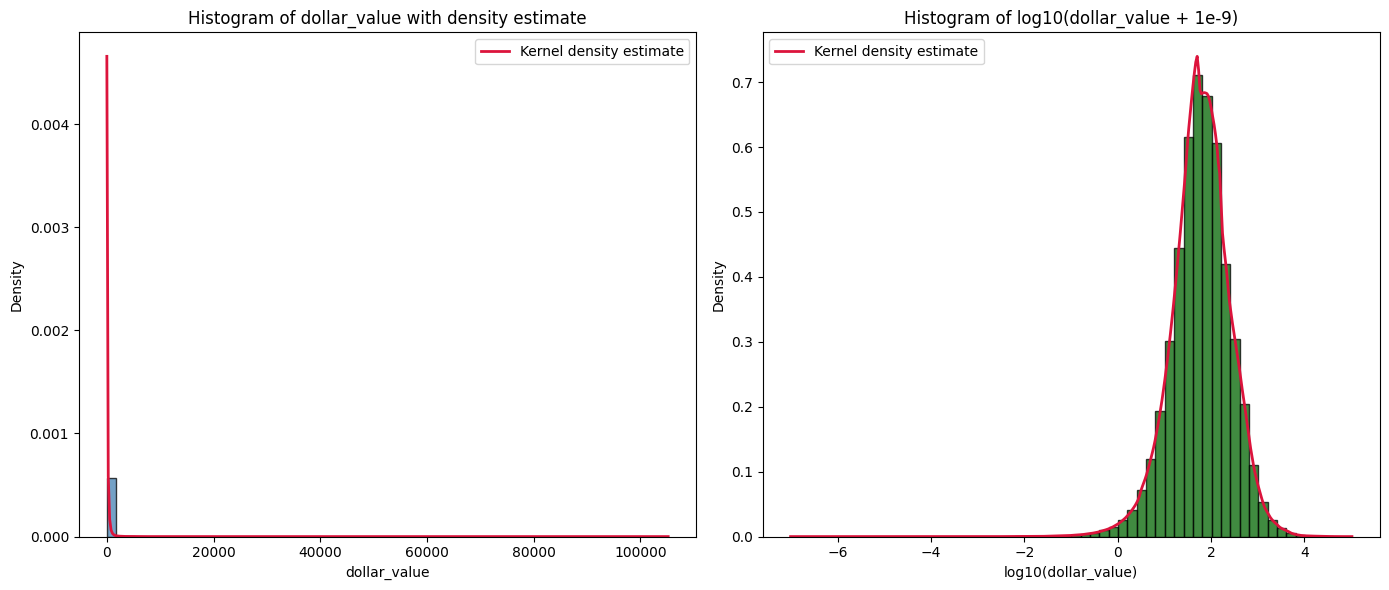

In [9]:
import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.stats import gaussian_kde
    use_scipy_kde = True
except ImportError:
    use_scipy_kde = False

values = datasets["transactions"].select("dollar_value").toPandas()["dollar_value"].dropna()
log_values = np.log10(values.where(values > 0).dropna() + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original dollar value histogram
axes[0].hist(values, bins=60, density=True, alpha=0.75, color="steelblue", edgecolor="black")
if use_scipy_kde:
    x = np.linspace(values.min(), values.max(), 400)
    density = gaussian_kde(values)
    axes[0].plot(x, density(x), color="crimson", linewidth=2, label="Kernel density estimate")
axes[0].set_title("Histogram of dollar_value with density estimate")
axes[0].set_xlabel("dollar_value")
axes[0].set_ylabel("Density")
axes[0].legend()

# Log10-transformed histogram
axes[1].hist(log_values, bins=60, density=True, alpha=0.75, color="darkgreen", edgecolor="black")
if use_scipy_kde:
    x_log = np.linspace(log_values.min(), log_values.max(), 400)
    density_log = gaussian_kde(log_values)
    axes[1].plot(x_log, density_log(x_log), color="crimson", linewidth=2, label="Kernel density estimate")
axes[1].set_title("Histogram of log10(dollar_value + 1e-9)")
axes[1].set_xlabel("log10(dollar_value)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()


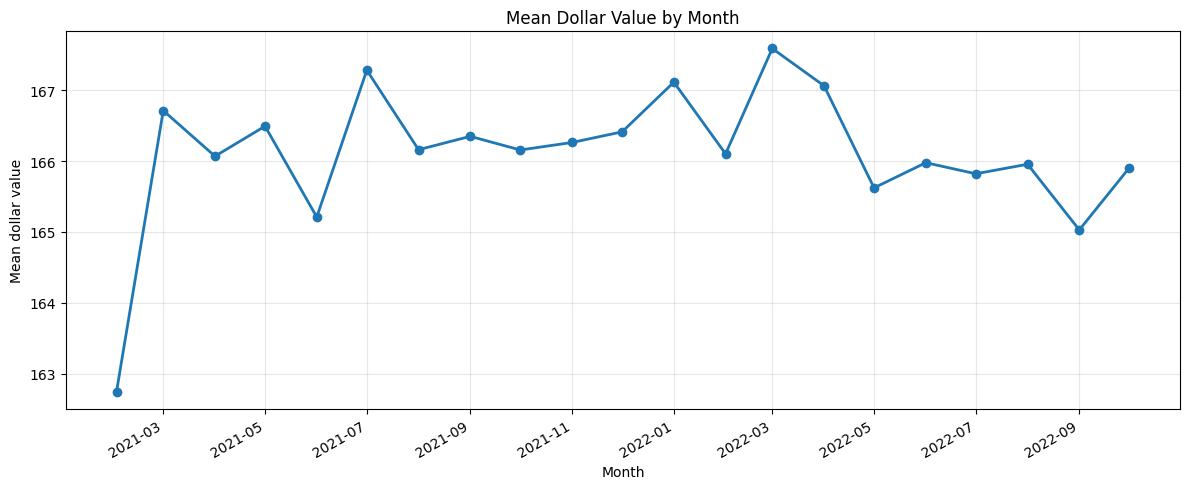

In [10]:
import matplotlib.pyplot as plt

monthly_mean = (
    transactions
    .where(F.col("order_datetime").isNotNull() & F.col("dollar_value").isNotNull())
    .withColumn("month", F.date_trunc("month", F.to_timestamp("order_datetime")))
    .groupBy("month")
    .agg(F.mean("dollar_value").alias("mean_dollar_value"))
    .orderBy("month")
)

monthly_mean_pd = monthly_mean.toPandas()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    monthly_mean_pd["month"],
    monthly_mean_pd["mean_dollar_value"],
    marker="o",
    linewidth=2,
)
ax.set_title("Mean Dollar Value by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Mean dollar value")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [11]:
# Combine parts 2-4 and write one Parquet data file.
part_dataframes = [
    read_partitioned_parquet(TABLES_DIR / part_name)
    for part_name in ["part_2", "part_3", "part_4"]
]
part_dataframes = [dataframe for dataframe in part_dataframes if dataframe is not None]

if len(part_dataframes) != 3:
    raise FileNotFoundError("Expected to find part_2, part_3, and part_4 under TABLES_DIR.")

combined_parts = part_dataframes[0]
for dataframe in part_dataframes[1:]:
    combined_parts = combined_parts.unionByName(dataframe, allowMissingColumns=True)

output_path = TABLES_DIR / "combined_parts_2_4.parquet"
(
    combined_parts
    .coalesce(1)
    .write
    .mode("overwrite")
    .parquet(str(output_path))
)

print(f"Saved combined parts 2-4 to: {output_path}")
print(f"Rows written: {combined_parts.count():,}")

Saved combined parts 2-4 to: /mnt/c/Users/werew/Downloads/MAST30034_Project_2/data/tables/combined_parts_2_4.parquet


Rows written: 14,195,505
